In [ ]:
!nvidia-smi

Sun Apr 19 10:39:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.4 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/yolo_v8

ls: cannot access '/content/drive/MyDrive/yolo_v8': No such file or directory


In [ ]:
import os, shutil, random

base_path = "/content/drive/MyDrive/yolo v8"

train_images = base_path + "/train/images"
train_labels = base_path + "/train/labels"

val_images = base_path + "/valid/images"
val_labels = base_path + "/valid/labels"

os.makedirs(val_images, exist_ok=True)
os.makedirs(val_labels, exist_ok=True)

images = os.listdir(train_images)
random.shuffle(images)

split_ratio = 0.2
val_size = int(len(images) * split_ratio)

for img in images[:val_size]:
    label = img.rsplit('.', 1)[0] + ".txt"

    shutil.move(os.path.join(train_images, img), os.path.join(val_images, img))
    shutil.move(os.path.join(train_labels, label), os.path.join(val_labels, label))

print(" Validation dataset created")

 Validation dataset created


In [ ]:
!cat /content/drive/MyDrive/yolo v8/data.yaml

cat: /content/drive/MyDrive/yolo: No such file or directory
cat: v8/data.yaml: No such file or directory


In [ ]:
yaml_path = base_path + "/data.yaml"

with open(yaml_path, "r") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 5
names: ['emulsion', 'oil', 'oil-platform', 'sheen', 'ship']

roboflow:
  workspace: samirs-workspace-9uzpu
  project: samirs-workspace-9uzpu
  version: dataset
  license: Private
  url: https://app.roboflow.com/samirs-workspace-9uzpu/samirs-workspace-9uzpu/dataset


In [ ]:
yaml_content = f"""
train: {base_path}/train/images
val: {base_path}/valid/images

nc: 5
names: ['emulsion', 'oil', 'oil-platform', 'sheen', 'ship']
"""

with open(base_path + "/data.yaml", "w") as f:
    f.write(yaml_content)

print("YAML fixed successfully!")

YAML fixed successfully!


In [ ]:
from ultralytics import YOLO

model = YOLO('yolo11m.pt')  # best for T4 + your dataset size

model.train(
    data="/content/drive/MyDrive/yolo v8/data.yaml",

    epochs=180,            # more training for small objects
    imgsz=832,             #  key for small object detection
    batch=8,               # reduced due to larger image size

    optimizer="AdamW",
    lr0=0.0007,            # stable learning
    lrf=0.01,

    weight_decay=0.0005,
    momentum=0.937,

    warmup_epochs=5,

    #  loss tuning (helps small objects)
    box=8.0,
    cls=0.6,
    dfl=1.5,

    # augmentation (important for 1000 images)
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    degrees=5,
    translate=0.1,
    scale=0.6,
    shear=1.5,

    fliplr=0.5,
    mosaic=1.0,
    mixup=0.2,

    patience=40,
    cos_lr=True,
    amp=True,

    workers=2
)

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=8.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.6, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/yolo v8/data.yaml, degrees=5, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=180, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=832, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0007, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e25c82bf020>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [ ]:
import os

output_dir = '/content/runs/detect/train-2/weights/'
print(f"The model weights are saved in: {output_dir}")

if os.path.exists(output_dir):
    print("Contents of the directory:")
    !ls -lh {output_dir}
else:
    print(f"Directory does not exist: {output_dir}")
    print("Please check the training output for the correct path, which was /content/runs/detect/train-2 in the previous cell.")

The model weights are saved in: /content/runs/detect/train-2/weights/
Contents of the directory:
total 78M
-rw-r--r-- 1 root root 39M Apr 19 14:44 best.pt
-rw-r--r-- 1 root root 39M Apr 19 14:44 last.pt



image 1/1 /keep.png: 448x832 1 oil, 1 ship, 35.7ms
Speed: 3.1ms preprocess, 35.7ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 832)
Results saved to /content/runs/detect/predict-9


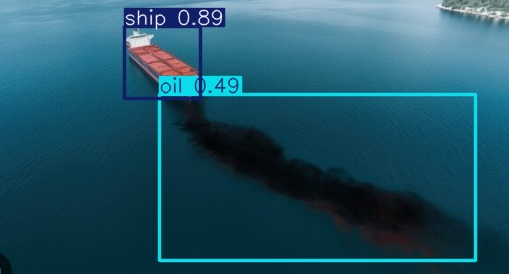

In [ ]:
from ultralytics import YOLO
from PIL import Image
from IPython.display import display
import glob
import os

# load model
model = YOLO("/content/runs/detect/train-2/weights/best.pt")

# run detection
results = model("/keep.png", save=True)

# get latest predict folder
predict_folders = glob.glob("/content/runs/detect/predict*")
latest_folder = max(predict_folders, key=os.path.getctime)

# get latest image inside that folder
image_files = glob.glob(f"{latest_folder}/*.jpg")
latest_image = max(image_files, key=os.path.getctime)

# display correct result
display(Image.open(latest_image))